# 01 · A SAXS detector image from dislocation loops and lines

This notebook takes the two dislocation populations built in `midas_ddd/notebooks/01_loops_and_lines.ipynb` and renders them on a transmission SAXS detector with `midas_saxs.simulate_frame`:

* **irradiation loops**: closed prismatic loops, whose small-angle amplitude is the distortion term *plus the Laue term* (Ehrhart, Trinkaus & Larson 1982). Exact at every q; verified.
* **deformation lines**: infinite lines in a periodic ExaDiS cell. An edge or mixed line scatters into a thin sheet perpendicular to itself; a screw does not scatter at all. A periodic line has an amplitude only on the simulation cell's reciprocal lattice, so the frame shows it at a stated resolution. **This treatment is preregistered and under adversarial verification; it is not established.** Nothing in this notebook says which population dominates a measurement: that comparison is a separate, registered study.

**Install:** `pip install "midas-ddd>=0.2" "midas-saxs[dislocations]>=0.2" matplotlib`

**Units:** q in Å⁻¹ on the detector, positions in µm inside the networks; intensities in electrons² per µm³ of sample once the two cells are put on a common footing (section 6).

In [1]:
import json
import math
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

import midas_ddd
import midas_saxs
from midas_ddd import cubic_stiffness, find_loops, read_paradis, validate_network
from midas_saxs import (Frame, SAXSGeometry, SpherePopulation, azimuthal_profile,
                        radial_average, simulate_frame)
from midas_saxs.strain_source import electron_density_per_A3, network_amplitudes

torch.set_default_dtype(torch.float64)
DDD_DATA = Path("../../midas_ddd/notebooks/data")          # the files that ship with notebook 1
DATA_4000B = DDD_DATA / "4000b" / "lines96"                 # 12 MB, regenerated on demand (section 5)
print("midas_ddd", midas_ddd.__version__, " midas_saxs", midas_saxs.__version__)

midas_ddd 0.1.1  midas_saxs 0.1.1


## 1 · Detector geometry

A 17 keV beam, 2 m to the detector, 128 × 128 pixels of 112.5 µm, beamstop 6 pixels. That covers |q| from about 0.003 to 0.044 Å⁻¹, the range where a 5 nm loop's form factor lives. Compare it with each network's `q_max_supported`: a polyline cannot describe scattering finer than its own segments.

In [2]:
HC_KEV_A = 12.398419843320026
GEOM = SAXSGeometry(lsd_um=2.0e6, bcy_px=64, bcz_px=64, px_um=112.5, wavelength_A=HC_KEV_A / 17.0,
                    n_pix_y=128, n_pix_z=128, beamstop_radius_px=6)
Q_MIN, Q_MAX = GEOM.q_range_inv_A
print(f"|q| on the panel: {Q_MIN:.4f} .. {Q_MAX:.4f} 1/A; pixel {2 * math.pi / GEOM.wavelength_A * GEOM.px_um / GEOM.lsd_um:.2e} 1/A")

|q| on the panel: 0.0029 .. 0.0439 1/A; pixel 4.85e-04 1/A


## 2 · Material

Copper: cubic stiffness (only the ratios matter for the amplitude) and the matrix electron density, which comes from `midas_hkls` form factors at s = 0 rather than from a typed-in Z.

In [3]:
CU = cubic_stiffness(168.4, 121.4, 75.4)                    # GPa
RHO_CU = electron_density_per_A3(["Cu"], [4], 3.615 ** 3)   # e / A^3
B_CU_A = 2.556
print(f"electron density {RHO_CU:.4f} e/A^3")


def show(frames, titles, *, floor_inv_A=None, vmin_rel=1e-6, suptitle=None):
    fig, axes = plt.subplots(1, len(frames), figsize=(5 * len(frames), 4.4), squeeze=False)
    for ax, fr, title in zip(axes[0], frames, titles):
        img = fr.intensity.detach().numpy().copy()
        img[~fr.mask.numpy()] = np.nan
        if floor_inv_A is not None:
            img[fr.q_magnitude.numpy() < floor_inv_A] = np.nan
        vmax = float(np.nanmax(img)) if np.isfinite(np.nanmax(img)) and np.nanmax(img) > 0 else 1.0
        ext = [Q_MIN * 0 - Q_MAX, Q_MAX, -Q_MAX, Q_MAX]
        im = ax.imshow(img, origin="lower", cmap="inferno", extent=ext,
                       norm=matplotlib.colors.LogNorm(vmin=vmax * vmin_rel, vmax=vmax))
        ax.set_title(title); ax.set_xlabel("q_y (1/A)"); ax.set_ylabel("q_z (1/A)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

electron density 2.4543 e/A^3


## 3 · Irradiation loops

The 167 prismatic loops from the ExaDiS run in notebook 1 (1000 b cell, 1e22 m⁻³, b = ½⟨110⟩, six variants). By default `simulate_frame` sums the intensities of the loops, which is what a beam much larger than the loop spacing measures; each loop's own amplitude is coherent.

Two things to look at. The radial average, which is what a 1-D detector reports, and the azimuthal profile of the loops of **one** Burgers variant: along a loop's own normal the amplitude is exactly zero. The beam is along lab x (`SAXSGeometry`'s convention), so q on the detector is transverse to leading order -- the null only comes out clean for a variant whose normal has **no** x-component, i.e. lies entirely in the detector plane. Of the six FCC ½⟨110⟩ variants, b ∥ [011] is one: its normal sits at 45° in (q_y, q_z), so those loops leave a dark line there. A variant with an x-component (e.g. [110]) never reaches θ = 0 at any pixel and only washes the contrast down to a factor of 2, not to zero -- worth knowing before picking one by eye. The six-variant average washes the null out entirely. That null is the one thing a 2-D frame buys over I(q), and it needs a single crystal and the right variant to survive.

167 loops, Burgers conserved True, q_max supported 0.673 1/A (panel needs 0.044)


loops frame: components ['loops'], 1.3 s; warnings: []


28 loops with b || [011]


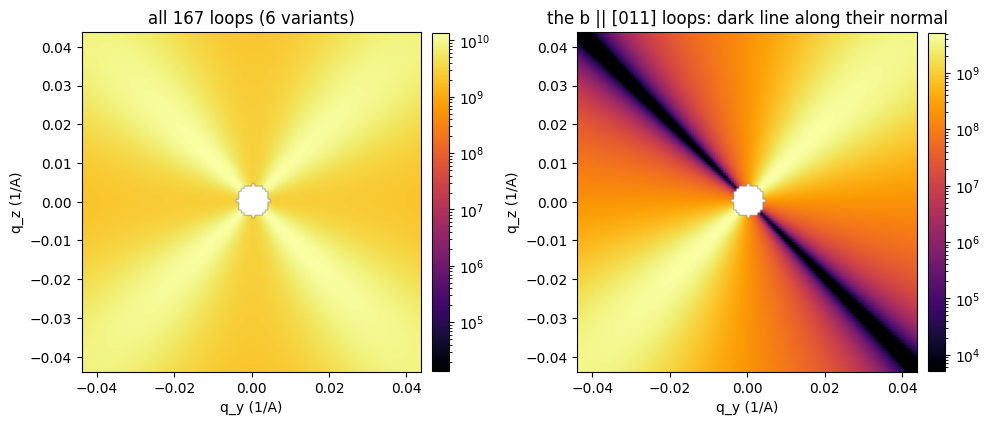

In [4]:
loops = read_paradis(DDD_DATA / "exadis_cu_loops.data", b_magnitude_A=B_CU_A)
s = validate_network(loops, q_max_inv_A=Q_MAX)
print(f"{s['n_loops']} loops, Burgers conserved {s['burgers_conserved']}, "
      f"q_max supported {s['resolution'].q_max_supported_inv_A:.3f} 1/A (panel needs {Q_MAX:.3f})")
t0 = time.time()
fr_loops = simulate_frame(GEOM, network=loops, stiffness=CU, electron_density_e_per_A3=RHO_CU)
print(f"loops frame: components {list(fr_loops.components)}, {time.time() - t0:.1f} s; warnings: {fr_loops.warnings}")

# one Burgers variant: rows of the per-loop amplitude with b || [011], the normal that
# lies entirely in the transverse (y, z) plane -- see the note above on why [110] would not
# show a clean null here, even though it is an equally valid FCC slip direction.
amps, info = network_amplitudes(loops, fr_loops.q[fr_loops.mask], CU, electron_density_e_per_A3=RHO_CU)
b_loop = torch.stack([lp.burgers_b for lp in find_loops(loops)])
sel = (b_loop @ torch.tensor([0.0, 1.0, 1.0]) / math.sqrt(2)).abs() > 0.99
I_one = torch.zeros_like(fr_loops.intensity)
I_one[fr_loops.mask] = (amps["loops"][sel].abs() ** 2).sum(dim=0)
fr_one = Frame(intensity=I_one, geometry=GEOM, q=fr_loops.q, mask=fr_loops.mask)
print(f"{int(sel.sum())} loops with b || [011]")
show([fr_loops, fr_one], ["all 167 loops (6 variants)", "the b || [011] loops: dark line along their normal"])

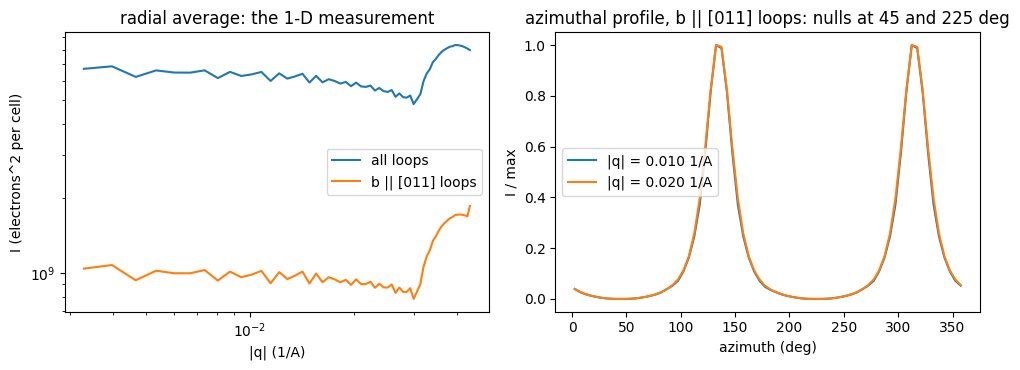

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8))
qc, I_r, n_px = radial_average(fr_loops, n_bins=60)
a1.loglog(qc.numpy(), I_r.numpy(), label="all loops")
qc1, I_r1, _ = radial_average(fr_one, n_bins=60)
a1.loglog(qc1.numpy(), I_r1.numpy(), label="b || [011] loops")
a1.set_xlabel("|q| (1/A)"); a1.set_ylabel("I (electrons^2 per cell)"); a1.set_title("radial average: the 1-D measurement"); a1.legend()
for q0 in (0.010, 0.020):
    az, I_az, _ = azimuthal_profile(fr_one, q_centre_inv_A=q0, q_width_inv_A=0.002, n_bins=72)
    a2.plot(az.numpy(), (I_az / I_az.max()).numpy(), label=f"|q| = {q0:.3f} 1/A")
a2.set_xlabel("azimuth (deg)"); a2.set_ylabel("I / max"); a2.set_title("azimuthal profile, b || [011] loops: nulls at 45 and 225 deg"); a2.legend()
plt.tight_layout(); plt.show()

## 4 · Deformation lines, first the negative example

The 24 lines that ship with notebook 1 are what ExaDiS's `generate_line_config` produces for Cu by default: **pure ⟨110⟩ screws**. A screw has no dilatation in isotropic or cubic elasticity, so it has no small-angle signal. The frame is float64 residue, and `simulate_frame` says so instead of drawing it. Read the warnings before the picture, always.

In [6]:
screws = read_paradis(DDD_DATA / "exadis_cu_lines.data", b_magnitude_A=B_CU_A)
t0 = time.time()
fr_screws = simulate_frame(GEOM, network=screws, stiffness=CU, electron_density_e_per_A3=RHO_CU)
print(f"components {list(fr_screws.components)}, peak {float(fr_screws.intensity.max()):.3e} electrons^2, {time.time() - t0:.1f} s")
for w in fr_screws.warnings:
    print("WARNING:", w)

components ['periodic_lines'], peak 5.341e-18 electrons^2, 6.1 s


## 5 · Deformation lines with mixed character

A population that scatters: 96 lines in a 4000 b (1.02 µm) cell, character angles drawn from {0, 30, 60, 90}°, 1.3e14 m⁻², generated by ExaDiS with `theta_deg` passed explicitly (`midas_ddd/notebooks/data/generate_exadis_cu_networks.py --box-b 4000 --loops 20 --lines 96 --theta-deg 0 30 60 90`). The file is 12 MB and is not shipped; the cell below prints that command and skips if it is absent.

What the frame shows and how it was made:

* each edge or mixed line contributes a sheet perpendicular to itself; on the panel those are streaks through the beam centre;
* the lines close through the periodic boundary, so their amplitude exists only on the cell's reciprocal lattice (spacing 2π/L). The frame is the replicated cell seen through a Gaussian window two lattice spacings wide, averaged over window placements (`periodic_resolution_fwhm_inv_A`; `frame.info["periodic"]` reports it);
* below `q_floor`, about three lattice spacings, the cell's own periodicity dominates. Those pixels are masked in the plot;
* each pixel averages about 27 lattice points, so the speckle of this one realisation is at the 20 % level.

96 periodic lines, 35766 segments, Burgers conserved True, q_max supported 0.123 1/A


components ['periodic_lines'], 86 s
resolution FWHM 1.23e-03 1/A, q_floor 2.01e-03 1/A, 280275 lattice points, median n_eff 27.3, above roundoff True


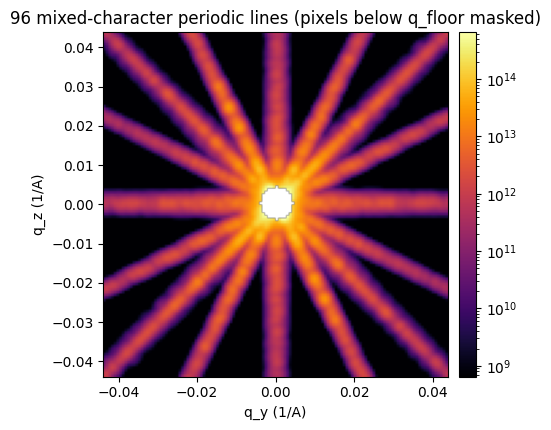

In [7]:
HAVE_LINES = (DATA_4000B / "exadis_cu_lines.data").exists()
if HAVE_LINES:
    lines = read_paradis(DATA_4000B / "exadis_cu_lines.data", b_magnitude_A=B_CU_A)
    s = validate_network(lines, q_max_inv_A=Q_MAX)
    print(f"{s['n_winding_lines']} periodic lines, {lines.n_segments} segments, Burgers conserved {s['burgers_conserved']}, "
          f"q_max supported {s['resolution'].q_max_supported_inv_A:.3f} 1/A")
    t0 = time.time()
    fr_lines = simulate_frame(GEOM, network=lines, stiffness=CU, electron_density_e_per_A3=RHO_CU)
    per = fr_lines.info["periodic"]
    print(f"components {list(fr_lines.components)}, {time.time() - t0:.0f} s")
    print(f"resolution FWHM {per['fwhm_inv_A']:.2e} 1/A, q_floor {per['q_floor_inv_A']:.2e} 1/A, "
          f"{per['n_lattice_points']} lattice points, median n_eff {per['n_eff_median']:.1f}, above roundoff {per['above_roundoff']}")
    for w in fr_lines.warnings:
        print("WARNING:", w)
    show([fr_lines], ["96 mixed-character periodic lines (pixels below q_floor masked)"], floor_inv_A=per["q_floor_inv_A"])
else:
    print("4000 b lines network not found at", DATA_4000B)
    print("regenerate with ExaDiS:  python generate_exadis_cu_networks.py --out <dir> --box-b 4000 --loops 20 --lines 96 --theta-deg 0 30 60 90")

## 6 · Loops and lines on one panel, per unit volume

The loops live in a 0.256 µm cell and the lines in a 1.02 µm cell. `simulate_frame` returns intensity per simulation cell, so the two are put on a common footing by dividing each by its cell volume. **Do not read a loops-versus-lines ratio off this picture.** It depends on the two densities chosen here (1e22 m⁻³ and 1.3e14 m⁻²), on q, and on the line treatment being verified; which population a measurement sees is the question of a separate registered study.

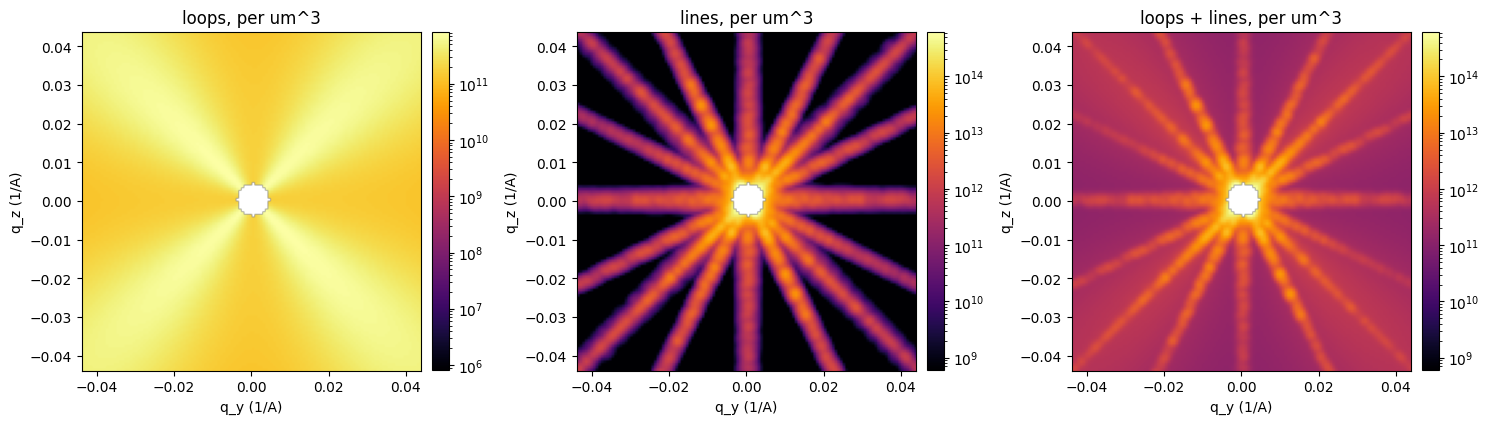

In [8]:
V_loops_um3 = loops.cell_volume_um3
per_um3 = {"loops": fr_loops.intensity / V_loops_um3}
if HAVE_LINES:
    per_um3["lines"] = fr_lines.intensity / lines.cell_volume_um3
frames, titles = [], []
for name, I in per_um3.items():
    frames.append(Frame(intensity=I, geometry=GEOM, q=fr_loops.q, mask=fr_loops.mask)); titles.append(f"{name}, per um^3")
if HAVE_LINES:
    total = per_um3["loops"] + per_um3["lines"]
    frames.append(Frame(intensity=total, geometry=GEOM, q=fr_loops.q, mask=fr_loops.mask)); titles.append("loops + lines, per um^3")
    show(frames, titles, floor_inv_A=fr_lines.info["periodic"]["q_floor_inv_A"])
else:
    show(frames, titles)

## 7 · Voids, for scale

In an irradiated metal the small-angle image is usually dominated by cavities, not by loops: a void of radius R displaces 4πR³/3, a loop of the same radius relaxes only πR²b, a factor 26 in volume and about 700 in intensity at R = 5 nm in Cu. The `SpherePopulation` below has the loops' radius and number density. Its intensity is per Å³ of sample, so `sample_volume_A3 = 1e12` gives electrons² per µm³, the same footing as section 6.

at |q| = 0.01 1/A: voids / loops (same radius and number density) = 4.18e+04


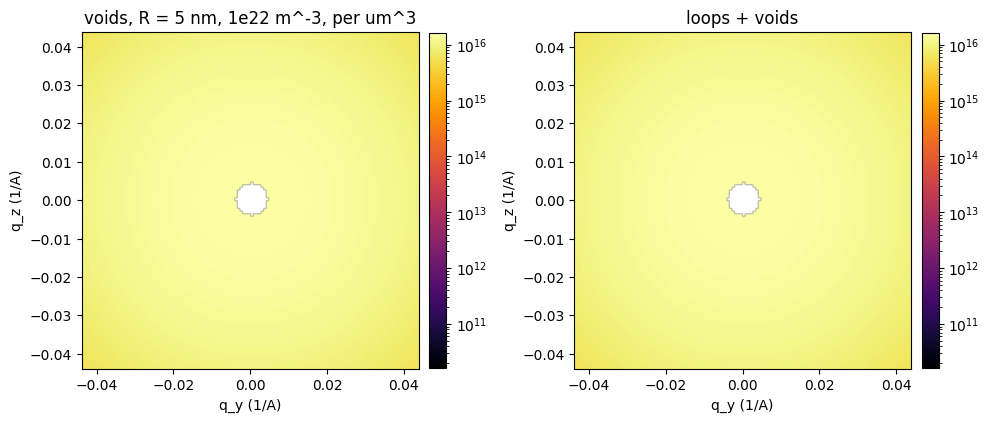

In [9]:
voids = SpherePopulation(radius_A=50.0, number_density_per_A3=1e-8, delta_rho_e_per_A3=-RHO_CU, label="voids")
fr_voids = simulate_frame(GEOM, particles=[voids], sample_volume_A3=1e12)
q0 = 0.010
_, I_v, _ = azimuthal_profile(fr_voids, q_centre_inv_A=q0, q_width_inv_A=0.002)
_, I_l, _ = azimuthal_profile(Frame(intensity=per_um3["loops"], geometry=GEOM, q=fr_loops.q, mask=fr_loops.mask),
                              q_centre_inv_A=q0, q_width_inv_A=0.002)
print(f"at |q| = {q0} 1/A: voids / loops (same radius and number density) = {float(I_v.mean() / I_l.mean()):.3g}")
show([fr_voids, Frame(intensity=per_um3["loops"] + fr_voids.intensity, geometry=GEOM, q=fr_loops.q, mask=fr_loops.mask)],
     ["voids, R = 5 nm, 1e22 m^-3, per um^3", "loops + voids"])

## 8 · The frame is differentiable

Everything above is torch. The gradient of any pixel sum with respect to the node coordinates, the Burgers vectors or the elastic constants comes from autograd, which is what an inversion trains against. One call, for the loops: the gradient of the total intensity with respect to every node position.

In [10]:
nodes = loops.nodes_um.clone().requires_grad_(True)
net_g = midas_ddd.DislocationNetwork(
    nodes_um=nodes, segments=loops.segments, burgers_b=loops.burgers_b, normals=loops.normals,
    b_magnitude_A=loops.b_magnitude_A, cell_min_um=loops.cell_min_um, cell_max_um=loops.cell_max_um,
    pbc=loops.pbc, constraints=loops.constraints)
t0 = time.time()
total = simulate_frame(GEOM, network=net_g, stiffness=CU, electron_density_e_per_A3=RHO_CU).intensity.sum()
total.backward()
g = nodes.grad
print(f"d(sum I)/d(nodes): shape {tuple(g.shape)}, finite {bool(torch.isfinite(g).all())}, "
      f"|grad| median {float(g.norm(dim=1).median()):.3e}, max {float(g.norm(dim=1).max()):.3e} electrons^2/um, {time.time() - t0:.1f} s")

d(sum I)/d(nodes): shape (4044, 3), finite True, |grad| median 2.745e+13, max 5.846e+13 electrons^2/um, 2.0 s


## Next

* **Which population dominates, and where in q:** a registered comparison with a physical (Burgers-conserving, screened) line population, verified before it is reported. Not this notebook.
* **Inversion:** the gradients above feed a fit of loop size, density and character to a measured frame; the identifiability study for that is in `midas_saxs/dev/paper`.
* **DFXM from the same networks:** `midas_dfxm/examples/exadis_to_dfxm.py`.

**What this notebook does not do:** absolute units (`absolute_units=True` multiplies by rₑ² if you need a cross-section), instrument resolution, multiple scattering, or a core model (the kernels are linear elastic and stop being right at q of a few inverse Burgers vectors; `validate_network` reports where).